# Proteomics-features

Plot proteomics feature distribution using the scDVP dataset as an example.

In [1]:
import alphapepttools as apt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
pg_path = apt.data.get_data("Weiss2026_pg_directLFQ")
metadata_path = apt.data.get_data("Weiss2026_metadata")
adata = apt.io.read_pg_table(pg_path, search_engine="directlfq")
metadata  = pd.read_csv(metadata_path, index_col=0)

adata = apt.pp.add_metadata(adata, metadata, axis=0)

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/publication/alphapepttools-manuscript/notebooks/analysis/extra/proteomics-properties/scDVP.report.tsv.protein_intensities.tsv already exists (37.4078893661499 MB)
/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/publication/alphapepttools-manuscript/notebooks/analysis/extra/proteomics-properties/metadata_scDVP.csv already exists (0.09111309051513672 MB)


In [3]:
apt.metrics.calculate_qc_metrics(adata)
adata.var["mean_feature_intensity"] = np.nanmean(adata.X, axis=0)

## Feature distribution
Approximately normal on a logscale

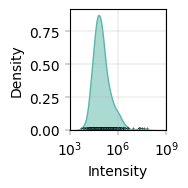

In [4]:
fig, axm = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))
x = adata.X[:, np.argmax(adata.var["fraction_detected_samples"])]
sns.kdeplot(x, color="#59B6A9", fill=True, alpha=0.5, log_scale=10, ax=axm[0])
sns.scatterplot(y=0.02, x=x, transform=plt.gca().get_xaxis_transform(), color="#307E74", lw=0.2, s=1, edgecolor="k", ax=axm[0])

axm[0].set_xticks([1e3, 1e6, 1e9])
apt.pl.label_axes(ax=plt.gca(), xlabel="Intensity", ylabel="Density")
fig.savefig("./feature-intensity-distribution.svg", bbox_inches="tight", transparent=True)
plt.show()

## Missingness distribution
Missing not at random with clear dependence on mean feature intensity

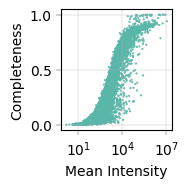

In [5]:
fig, axm = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))


apt.pl.scatter(
    adata.var, "mean_feature_intensity", "fraction_detected_samples", color="#59B6A9", scatter_kwargs={"s": 0.3}, ax=axm[0]
)
apt.pl.label_axes(ax=plt.gca(), xlabel="Mean Intensity", ylabel="Completeness")

axm[0].semilogx()
axm[0].set_xticks([1e1, 1e4, 1e7])
fig.savefig("./feature-missingness-distribution.svg", bbox_inches="tight", transparent=True)
plt.show()